In [1]:
import zipfile
import os

zip_path="/content/archive (20).zip"
extract_path="/content"

with zipfile.ZipFile(zip_path,"r") as zip_ref:
  zip_ref.extractall(extract_path)

print(os.listdir("/content"))


['.config', 'archive (20).zip', 'data_moods.csv', 'data', 'sample_data']


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

train_dir = "/content/data/train"
test_dir = "/content/data/test"

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1)
    ),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder(train_dir, transform=train_transform)
test_data = datasets.ImageFolder(test_dir, transform=test_transform)

train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_data,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Classes:", train_data.classes)
num_classes = len(train_data.classes)

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, num_classes)
)

model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.00005,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

epochs = 25
best_test_acc = 0
patience = 5
no_improve_count = 0

for epoch in range(epochs):
    model.train()

    train_correct = 0
    train_total = 0
    total_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)

    train_acc = 100 * train_correct / train_total

    model.eval()

    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            test_correct += (predicted == labels).sum().item()
            test_total += labels.size(0)

    test_acc = 100 * test_correct / test_total

    scheduler.step(test_acc)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        no_improve_count = 0
        torch.save(model.state_dict(), "best_resnet18_emotion_model.pth")
    else:
        no_improve_count += 1

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch+1}/{epochs}], "
        f"Loss: {total_loss:.4f}, "
        f"Train Acc: {train_acc:.2f}%, "
        f"Test Acc: {test_acc:.2f}%, "
        f"LR: {current_lr}"
    )

    if no_improve_count >= patience:
        print("Early stopping triggered")
        break

print("Best Test Accuracy:", best_test_acc)
print("Best model saved as best_resnet18_emotion_model.pth")

Device: cpu
Classes: ['0', '1', '2', '3', '4', '5', '6']
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 147MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [18]:
torch.save(model.state_dict(), "best_resnet18_emotion_model.pth")
print("Model saved as emotion_model.pth")
print("Classes:", train_data.classes)

Model saved as emotion_model.pth
Classes: ['0', '1', '2', '3', '4', '5', '6']


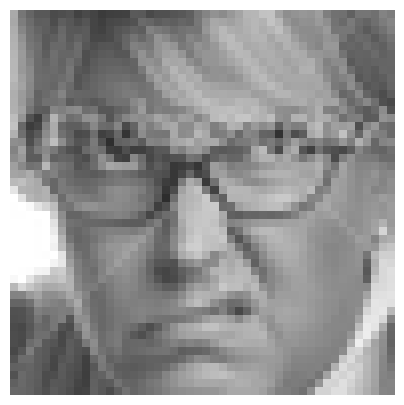

Predicted Emotion: angry
Confidence: 93.61%


In [27]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_names = {
    0: "angry",
    1: "disgust",
    2: "fear",
    3: "happy",
    4: "sad",
    5: "surprise",
    6: "neutral"
}

model = models.resnet18(weights=None)

model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, 7)
)

model.load_state_dict(
    torch.load("best_resnet18_emotion_model.pth", map_location=device)
)

model = model.to(device)
model.eval()

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

image_path = "32298.png"  # change image name

# Display image
img = Image.open(image_path).convert("RGB")

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.show()

# Prediction
image = transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(image)
    probabilities = torch.softmax(outputs, dim=1)
    confidence, predicted = torch.max(probabilities, 1)

emotion = class_names[predicted.item()]

print("Predicted Emotion:", emotion)
print("Confidence:", f"{confidence.item()*100:.2f}%")

In [ ]:
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        test_correct += (predicted == labels).sum().item()
        test_total += labels.size(0)

test_acc = 100 * test_correct / test_total

print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss:.4f}, Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}%")

Epoch [50/50], Loss: 567.7152, Train Acc: 76.40%, Test Acc: 62.66%


In [23]:
import pandas as pd
df=pd.read_csv("/content/data_moods.csv")

In [25]:
df.head()
print(df.columns)

Index(['name', 'album', 'artist', 'id', 'release_date', 'popularity', 'length',
       'danceability', 'acousticness', 'energy', 'instrumentalness',
       'liveness', 'valence', 'loudness', 'speechiness', 'tempo', 'key',
       'time_signature', 'mood'],
      dtype='object')


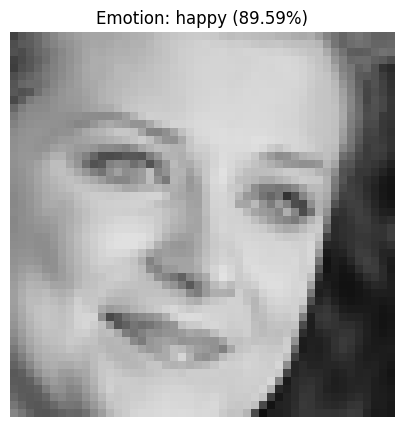

Detected Emotion: happy
Confidence: 89.59%
Mapped Music Mood: Happy


,name,artist,album,release_date,popularity,mood,similarity
533,Talking In Your Sleep,The Romantics,In Heat,1983-02-14,61,Happy,0.882724
223,Groove Is in the Heart,Deee-Lite,Rhino Hi-Five: Deee-Lite,2005-04-19,65,Happy,0.881720
93,Clap Your Hands,Sia,Clap Your Hands,2010-04-09,44,Happy,0.862764
299,Late in the Evening,Paul Simon,One-Trick Pony,1980-08-01,60,Happy,0.852321
208,Get Lucky (feat. Pharrell Williams & Nile Rodg...,Daft Punk,Get Lucky (feat. Pharrell Williams & Nile Rodg...,2013-04-19,78,Happy,0.846624
503,Start Me Up - Remastered,The Rolling Stones,Tattoo You (2009 Re-Mastered),1981-08-24,77,Happy,0.840826
478,Should I Stay or Should I Go - Remastered,The Clash,Hits Back,2013-08-26,68,Happy,0.827240
153,Driver's Seat,Sniff 'n' The Tears,Fickle Heart (Plus Two Bonus Cuts),1978,56,Happy,0.823296
228,Happy Ending,Joe Jackson,Body And Soul,1984-01-01,51,Happy,0.821372
83,Butterfly,Crazy Town,The Gift Of Game,1999-11-04,71,Happy,0.808062


In [30]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# MODEL 1: EMOTION DETECTION
# -------------------------

class_names = {
    0: "sad",
    1: "angry",
    2: "neutral",
    3: "happy",
    4: "fear",
    5: "disgust",
    6: "surprise"
}

emotion_model = models.resnet18(weights=None)

emotion_model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(emotion_model.fc.in_features, 7)
)

emotion_model.load_state_dict(
    torch.load("best_resnet18_emotion_model.pth", map_location=device)
)

emotion_model = emotion_model.to(device)
emotion_model.eval()

emotion_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def predict_emotion(image_path):
    img = Image.open(image_path).convert("RGB")

    image_tensor = emotion_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = emotion_model(image_tensor)
        probabilities = torch.softmax(output, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

    emotion = class_names[predicted.item()]
    confidence = confidence.item() * 100

    return emotion, confidence, img


# -------------------------
# MODEL 2: SONG RECOMMENDER
# -------------------------

df = pd.read_csv("data_moods.csv")

features = [
    'popularity', 'length', 'danceability', 'acousticness',
    'energy', 'instrumentalness', 'liveness', 'valence',
    'loudness', 'speechiness', 'tempo', 'key', 'time_signature'
]

df = df.dropna(subset=features + ["mood"])

scaler = StandardScaler()
song_features = scaler.fit_transform(df[features])

emotion_to_mood = {
    "happy": "Happy",
    "sad": "Sad",
    "angry": "Calm",
    "fear": "Calm",
    "disgust": "Calm",
    "neutral": "Calm",
    "surprise": "Energetic"
}

def recommend_songs(detected_emotion, top_n=10):
    required_mood = emotion_to_mood[detected_emotion]

    mood_songs = df[df["mood"] == required_mood].copy()

    if mood_songs.empty:
        return pd.DataFrame(), required_mood

    mood_indices = mood_songs.index.tolist()
    mood_vectors = song_features[mood_indices]

    user_vector = mood_vectors.mean(axis=0).reshape(1, -1)

    similarity_scores = cosine_similarity(user_vector, mood_vectors)[0]

    mood_songs["similarity"] = similarity_scores

    recommendations = mood_songs.sort_values(
        by=["similarity", "popularity"],
        ascending=False
    ).head(top_n)

    return recommendations[[
        "name", "artist", "album", "release_date",
        "popularity", "mood", "similarity"
    ]], required_mood


# -------------------------
# FINAL TEST
# -------------------------

image_path = "/content/32379.png"  # change this image name

emotion, confidence, img = predict_emotion(image_path)

songs, music_mood = recommend_songs(emotion, top_n=10)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"Emotion: {emotion} ({confidence:.2f}%)")
plt.axis("off")
plt.show()

print("Detected Emotion:", emotion)
print("Confidence:", f"{confidence:.2f}%")
print("Mapped Music Mood:", music_mood)

songs